In [140]:
# Diagnostic cell — run this in one cell to confirm envs and test AzureChatOpenAI
from dotenv import load_dotenv
import os, traceback
from langchain_openai import AzureChatOpenAI 
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
import operator

load_dotenv()  # ensure .env loaded

print("AZURE_OPENAI_KEY present:", bool(os.getenv("AZURE_OPENAI_KEY")))
print("AZURE_OPENAI_ENDPOINT:", os.getenv("AZURE_OPENAI_ENDPOINT"))
print("AZURE_OPENAI_DEPLOYMENT:", os.getenv("AZURE_OPENAI_DEPLOYMENT"))
print("AZURE_OPENAI_API_VERSION:", os.getenv("AZURE_OPENAI_API_VERSION"))
print("OPENAI_API_KEY (if set):", bool(os.getenv("OPENAI_API_KEY")))

# Map env names the SDK might look for (non-destructive)
if os.getenv("AZURE_OPENAI_KEY") and not os.getenv("AZURE_OPENAI_API_KEY"):
    os.environ["AZURE_OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_KEY")
if os.getenv("AZURE_OPENAI_KEY") and not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = os.getenv("AZURE_OPENAI_KEY")

# Instantiate explicitly with api_key to avoid env name issues
try:
    model = AzureChatOpenAI(
        azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-12-01-preview"),
        temperature=0.2,
        api_key=os.getenv("AZURE_OPENAI_KEY"),  # explicit
    )
    print('AzureChatOpenAI instantiated OK')
    
except Exception as e:
    print('Failed to instantiate AzureChatOpenAI:')
    traceback.print_exc()

# Try a short call (small tokens) to test end-to-end
try:
    resp = model.invoke("Say hello in one short sentence.")
    print("Invoke result:", getattr(resp, "content", None) or resp)
except Exception as e:
    print('Error during invoke:')
    traceback.print_exc()

AZURE_OPENAI_KEY present: True
AZURE_OPENAI_ENDPOINT: https://crr-openai-esg.openai.azure.com/
AZURE_OPENAI_DEPLOYMENT: gpt-4o-mini
AZURE_OPENAI_API_VERSION: 2024-12-01-preview
OPENAI_API_KEY (if set): True
AzureChatOpenAI instantiated OK
Invoke result: Hello!


In [141]:
class sentimentschema(BaseModel):
    sentiment : Literal["positive","negetive"]=Field(description='senttiment of the review')
    
    

In [142]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [143]:
structure_model = model.with_structured_output(sentimentschema)
structure_model2 = model.with_structured_output(DiagnosisSchema)

In [144]:
# promt = 'what is the sentiment of the the following review -  The software too bad'
# structure_model.invoke(promt)

In [145]:
class ReviewState(TypedDict):
    review : str
    sentiment : Literal["positive" , "negative"]
    diagnosis : dict
    response  : str
    

In [146]:
def find_sentiment(state:ReviewState):
    promt = f' For the following review find out the sentiment \n {state["review"]}'
    sentiment = structure_model.invoke(promt)
    return {'sentiment':sentiment}

In [147]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [148]:
def positive_response(state:ReviewState):
    promt = f"Write a warm Thank-you message in response to this review:{state['review']} Also kindly ask the user to leave the feedback on our website"
    response =model.invoke(promt).content
    return {'response':response}

In [149]:
def run_diagnosis(state : ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    response = structure_model2.invoke(prompt)
    return { 'diagnosis': response.model_dump()}


In [150]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt).content
    return {"response":response}



    

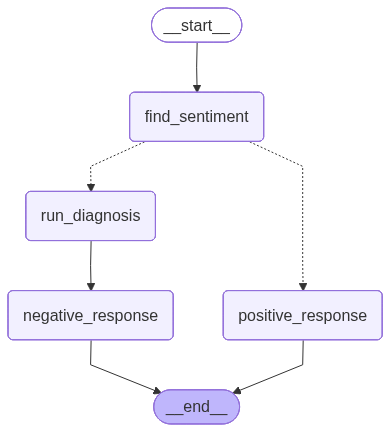

In [151]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_node('positive_response',positive_response)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)


workflow = graph.compile()

workflow

In [152]:

intial_state={
    'review': " images sometimes take a few seconds to load and the UI feels slightly sluggish occasionally — not urgent."
}
workflow.invoke(intial_state)

{'review': ' images sometimes take a few seconds to load and the UI feels slightly sluggish occasionally — not urgent.',
 'sentiment': sentimentschema(sentiment='negetive'),
 'diagnosis': {'issue_type': 'Performance', 'tone': 'calm', 'urgency': 'low'},
 'response': "Subject: We're Here to Help with Your Performance Issue\n\nHi [User's Name],\n\nThank you for reaching out to us regarding the performance issue you’ve been experiencing. I understand how frustrating it can be when things don’t work as smoothly as they should, and I appreciate your calm approach in addressing this.\n\nTo help us resolve the issue effectively, could you please provide a bit more detail? Specifically, it would be helpful to know:\n\n1. The specific performance issues you’re encountering (e.g., slow loading times, application crashes, etc.).\n2. The device and operating system you’re using.\n3. Any steps you’ve already taken to troubleshoot the problem.\n\nOnce I have this information, I’ll do my best to assis